# Distribution Fitting with Data Transformations

Notebook 01 showed that both lognormal and ensemble distributions
overestimate F3/F4 fibrosis prevalence (NHANES: 3.3% F4 vs.
lognormal sim: ~6.3%, ensemble: ~4.6%). The problem: vivarium's
ensemble parameterizes each distribution from mean and SD of the
raw data, and the heavy right skew of LSM makes that
parameterization inaccurate in the upper tail.

**Idea:** transform the data (sqrt, log) before fitting so the
transformed values are more symmetric. Fit distributions in the
transformed space, sample, then inverse-transform back to kPa.
If the fit is better in transformed space, the inverse-transformed
samples should better reproduce the empirical fibrosis fractions.

## Approach

1. Load NHANES liver stiffness data (same as notebook 01)
2. Visualize the effect of sqrt and log transforms on skewness
3. For each transform × distribution, fit via MLE and via mean/SD
4. Compare fibrosis staging (F0–F4) to empirical NHANES fractions
5. Q-Q plots for the best candidates

## 1. Load NHANES Data

In [1]:
import os, hashlib, warnings
import requests
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats

warnings.filterwarnings('ignore', category=FutureWarning)
pd.options.mode.chained_assignment = None

DATA_DIR   = os.path.abspath(os.path.join('..', 'data'))
RAW_NHANES = os.path.join(DATA_DIR, 'raw', 'nhanes')
NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'


def download(url, dest):
    if os.path.exists(dest):
        return dest
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    return dest


def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df


CYCLES = [
    {'label': '2017-2020', 'dirname': '2017_2020_prepandemic',
     'year': 2017, 'prefix': 'P_', 'suffix': '', 'files': ['DEMO', 'LUX']},
    {'label': '2021-2022', 'dirname': '2021_2022',
     'year': 2021, 'prefix': '', 'suffix': '_L', 'files': ['DEMO', 'LUX']},
]

dfs = []
for cyc in CYCLES:
    cdir = os.path.join(RAW_NHANES, cyc['dirname'])
    os.makedirs(cdir, exist_ok=True)
    fname = lambda c: f"{cyc['prefix']}{c}{cyc['suffix']}.xpt"
    furl  = lambda c: f"{NHANES_BASE}/{cyc['year']}/DataFiles/{fname(c)}"

    demo = read_xpt(download(furl('DEMO'), os.path.join(cdir, fname('DEMO'))))
    lux  = read_xpt(download(furl('LUX'),  os.path.join(cdir, fname('LUX'))))
    lux  = lux[['SEQN', 'LUXSMED']].rename(columns={'LUXSMED': 'LSM_KPA'})

    df = demo.merge(lux, on='SEQN', how='left')
    df = df[df['RIDSTATR'] == 2].copy()
    df['AGE'] = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['SEX'] = df['RIAGENDR'].map({1: 'Male', 2: 'Female'})
    wt_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    df['WEIGHT'] = df[wt_col]
    dfs.append(df[['SEQN', 'AGE', 'SEX', 'LSM_KPA', 'WEIGHT']])

nhanes_lsm = pd.concat(dfs, ignore_index=True).dropna(subset=['LSM_KPA', 'WEIGHT']).copy()

GBD_AGE_BINS = [
    (15, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45), (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 80), (80, 85),
]
nhanes_lsm['age_group'] = pd.cut(
    nhanes_lsm['AGE'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

print(f'Analytic sample: {len(nhanes_lsm):,} adults with valid LSM')

Analytic sample: 14,192 adults with valid LSM


In [2]:
FIBROSIS_BINS = [0, 6, 8, 10, 14, np.inf]
FIBROSIS_LABELS = ['F0', 'F1', 'F2', 'F3', 'F4']
FIBROSIS_COLORS = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
VCTE_CUTOFFS = [6, 8, 10, 14]


def fibrosis_fractions(values, weights=None):
    cats = pd.cut(values, bins=FIBROSIS_BINS, labels=FIBROSIS_LABELS, right=False)
    if weights is not None:
        total = weights.sum()
        return pd.Series({lab: float(weights[cats == lab].sum() / total)
                          for lab in FIBROSIS_LABELS})
    n = len(values)
    return pd.Series({lab: float((cats == lab).sum() / n)
                      for lab in FIBROSIS_LABELS})


def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_std(values, weights):
    avg = weighted_mean(values, weights)
    return np.sqrt(np.average((values - avg) ** 2, weights=weights))


nhanes_fibrosis = fibrosis_fractions(
    nhanes_lsm['LSM_KPA'].values, nhanes_lsm['WEIGHT'].values)

print('NHANES fibrosis staging (weighted):')
for lab in FIBROSIS_LABELS:
    print(f'  {lab}: {nhanes_fibrosis[lab]:.2%}')

NHANES fibrosis staging (weighted):
  F0: 70.60%
  F1: 17.81%
  F2: 4.76%
  F3: 3.54%
  F4: 3.29%


## 2. Why Transform? Visualizing Skewness

The raw LSM distribution is heavily right-skewed. Parametric
distributions fitted via mean/SD struggle with such skew because
the mean is pulled rightward by high-LSM outliers, inflating the
fitted variance and the right tail.

Sqrt and log transforms compress the right tail, producing a more
symmetric distribution that standard families (normal, gamma, etc.)
can capture more faithfully.

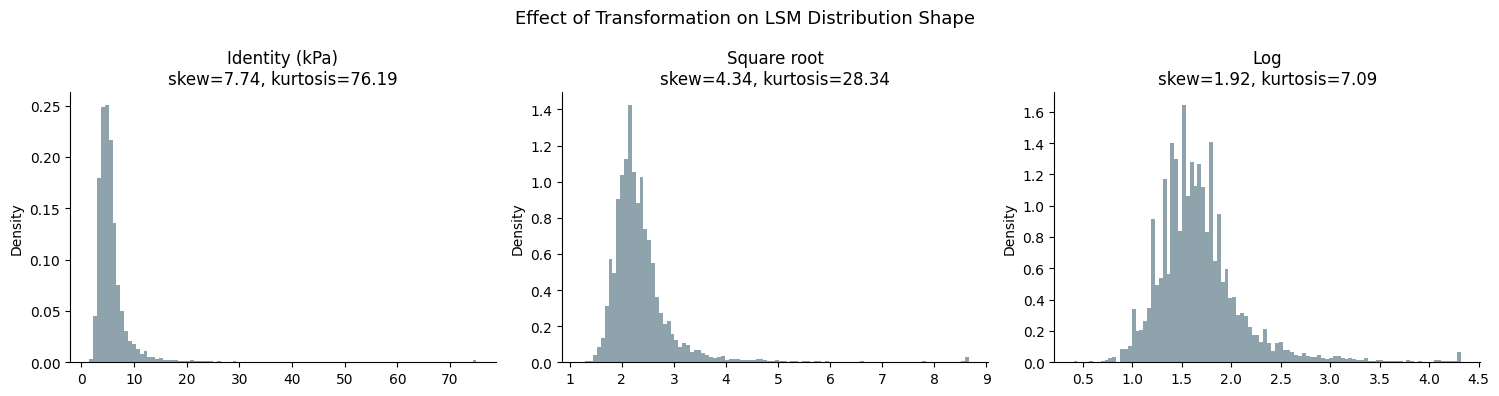

In [3]:
data_all = nhanes_lsm['LSM_KPA'].values

TRANSFORMS = [
    ('Identity (kPa)',  lambda x: x,          lambda y: y),
    ('Square root',     lambda x: np.sqrt(x), lambda y: y ** 2),
    ('Log',             lambda x: np.log(x),  lambda y: np.exp(y)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, fwd, _) in zip(axes, TRANSFORMS):
    vals = fwd(data_all)
    ax.hist(vals, bins=100, density=True, alpha=0.7, color='#607D8B')
    skew = sp_stats.skew(vals)
    kurt = sp_stats.kurtosis(vals)
    ax.set_title(f'{name}\nskew={skew:.2f}, kurtosis={kurt:.2f}')
    ax.set_ylabel('Density')
    sns.despine(ax=ax)

plt.suptitle('Effect of Transformation on LSM Distribution Shape', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Systematic Experiment: Transform × Distribution × Fitting Method

For each age/sex stratum, we test every combination of:

- **Transform**: identity, sqrt, log
- **Distribution**: normal, lognormal, log-logistic, gamma, Weibull
- **Fitting method**:
  - **MLE** (scipy `dist.fit`) — maximum likelihood, best possible fit
  - **Mean/SD** (vivarium-compatible) — parameterize from weighted mean and
    SD only, as vivarium's `risk_distributions` does

For each combination we sample 10,000 values from the fitted distribution,
inverse-transform to kPa, and compare fibrosis staging to NHANES.

The MLE fits show the ceiling — how well a distribution *can* fit the data.
The mean/SD fits show what vivarium would actually produce.

In [4]:
DISTS = {
    'normal':      (sp_stats.norm,       {}),
    'lognormal':   (sp_stats.lognorm,    {'floc': 0}),
    'log-logistic':(sp_stats.fisk,       {'floc': 0}),
    'gamma':       (sp_stats.gamma,      {'floc': 0}),
    'weibull':     (sp_stats.weibull_min, {'floc': 0}),
}

N_SAMPLE = 50_000  # large sample to reduce MC noise
rng = np.random.default_rng(42)

results = []

for t_name, fwd, inv in TRANSFORMS:
    for d_name, (dist, fit_kw) in DISTS.items():
        # Pool across all age/sex strata for a single aggregate comparison,
        # but also do per-stratum to accumulate weighted fibrosis fractions
        all_samples_mle = []
        all_samples_ms = []
        all_weights = []
        mle_ok = True
        ms_ok = True

        for (age_grp, sex), g in nhanes_lsm.groupby(
                ['age_group', 'SEX'], observed=True):
            raw = g['LSM_KPA'].values
            w = g['WEIGHT'].values
            n_stratum = len(raw)
            t_data = fwd(raw)

            # --- MLE fit ---
            try:
                params = dist.fit(t_data, **fit_kw)
                t_samples = dist.rvs(*params, size=n_stratum,
                                     random_state=rng)
                kpa_samples = inv(t_samples)
                # Drop invalid (NaN, negative, inf)
                valid = np.isfinite(kpa_samples) & (kpa_samples > 0)
                if valid.sum() < n_stratum * 0.5:
                    mle_ok = False
                else:
                    all_samples_mle.append(kpa_samples[valid])
            except Exception:
                mle_ok = False

            # --- Mean/SD fit (vivarium-style) ---
            try:
                mu = weighted_mean(t_data, w)
                sd = weighted_std(t_data, w)
                if sd <= 0 or not np.isfinite(mu):
                    ms_ok = False
                    continue

                # Parameterize from mean/SD (what vivarium does)
                if dist == sp_stats.norm:
                    ms_params = (mu, sd)
                elif dist == sp_stats.lognorm:
                    # mean/SD of data -> lognormal shape params
                    # If data is already log-transformed, normal is better
                    alpha = 1 + (sd / mu) ** 2
                    if alpha <= 0 or mu <= 0:
                        ms_ok = False
                        continue
                    s = np.sqrt(np.log(alpha))
                    scale = mu / np.sqrt(alpha)
                    ms_params = (s, 0, scale)
                elif dist == sp_stats.gamma:
                    if mu <= 0:
                        ms_ok = False
                        continue
                    a = (mu / sd) ** 2
                    scale = sd ** 2 / mu
                    ms_params = (a, 0, scale)
                elif dist == sp_stats.weibull_min:
                    # Use MLE for shape, set scale from mean/SD
                    mle_p = dist.fit(t_data, **fit_kw)
                    ms_params = mle_p  # fallback to MLE
                elif dist == sp_stats.fisk:
                    mle_p = dist.fit(t_data, **fit_kw)
                    ms_params = mle_p  # fallback to MLE
                else:
                    ms_ok = False
                    continue

                t_samples = dist.rvs(*ms_params, size=n_stratum,
                                     random_state=rng)
                kpa_samples = inv(t_samples)
                valid = np.isfinite(kpa_samples) & (kpa_samples > 0)
                if valid.sum() < n_stratum * 0.5:
                    ms_ok = False
                else:
                    all_samples_ms.append(kpa_samples[valid])
            except Exception:
                ms_ok = False

        # Compute fibrosis fractions from pooled samples
        for method, samples_list, ok in [
            ('MLE', all_samples_mle, mle_ok),
            ('mean/SD', all_samples_ms, ms_ok),
        ]:
            if ok and samples_list:
                pooled = np.concatenate(samples_list)
                fib = fibrosis_fractions(pooled)
                results.append({
                    'transform': t_name.split(' ')[0].lower(),
                    'distribution': d_name,
                    'method': method,
                    'n_samples': len(pooled),
                    **{lab: fib[lab] for lab in FIBROSIS_LABELS},
                })

results_df = pd.DataFrame(results)
print(f'Completed {len(results_df)} experiments')

Completed 30 experiments


## 4. Results: Which Combination Best Matches NHANES Fibrosis Staging?

In [5]:
# Compute error vs NHANES for each fibrosis stage
for lab in FIBROSIS_LABELS:
    results_df[f'{lab}_err'] = results_df[lab] - nhanes_fibrosis[lab]

# Total absolute error across F3 + F4 (the stages we care most about)
results_df['F3F4_abs_err'] = (
    results_df['F3_err'].abs() + results_df['F4_err'].abs()
)
# Total absolute error across all stages
results_df['total_abs_err'] = sum(
    results_df[f'{lab}_err'].abs() for lab in FIBROSIS_LABELS
)

# Display sorted by F3+F4 error
display_cols = ['transform', 'distribution', 'method',
                'F0', 'F1', 'F2', 'F3', 'F4',
                'F3F4_abs_err', 'total_abs_err']

print('All experiments sorted by F3+F4 absolute error:')
print(f'NHANES target: F3={nhanes_fibrosis["F3"]:.2%}, F4={nhanes_fibrosis["F4"]:.2%}\n')

display(results_df[display_cols]
        .sort_values('F3F4_abs_err')
        .style.format({
            'F0': '{:.1%}', 'F1': '{:.1%}', 'F2': '{:.1%}',
            'F3': '{:.1%}', 'F4': '{:.1%}',
            'F3F4_abs_err': '{:.3f}', 'total_abs_err': '{:.3f}',
        })
        .background_gradient(subset=['F3F4_abs_err'], cmap='RdYlGn_r')
)

All experiments sorted by F3+F4 absolute error:
NHANES target: F3=3.54%, F4=3.29%



,transform,distribution,method,F0,F1,F2,F3,F4,F3F4_abs_err,total_abs_err
25,log,log-logistic,mean/SD,69.7%,18.1%,6.2%,3.7%,2.2%,0.012,0.039
24,log,log-logistic,MLE,69.5%,18.3%,6.1%,3.8%,2.3%,0.013,0.042
23,log,lognormal,mean/SD,66.1%,17.5%,7.8%,5.4%,3.2%,0.020,0.098
15,square,log-logistic,mean/SD,67.8%,20.5%,6.9%,3.5%,1.2%,0.021,0.097
4,identity,log-logistic,MLE,67.9%,20.7%,6.7%,3.5%,1.1%,0.022,0.097
14,square,log-logistic,MLE,68.1%,20.1%,7.2%,3.6%,1.0%,0.024,0.096
22,log,lognormal,MLE,66.2%,18.8%,7.6%,5.0%,2.4%,0.024,0.106
27,log,gamma,mean/SD,64.5%,19.0%,8.0%,5.7%,2.8%,0.026,0.132
5,identity,log-logistic,mean/SD,68.1%,19.9%,6.9%,3.9%,1.1%,0.026,0.094
26,log,gamma,MLE,63.6%,20.3%,8.3%,5.6%,2.1%,0.033,0.164


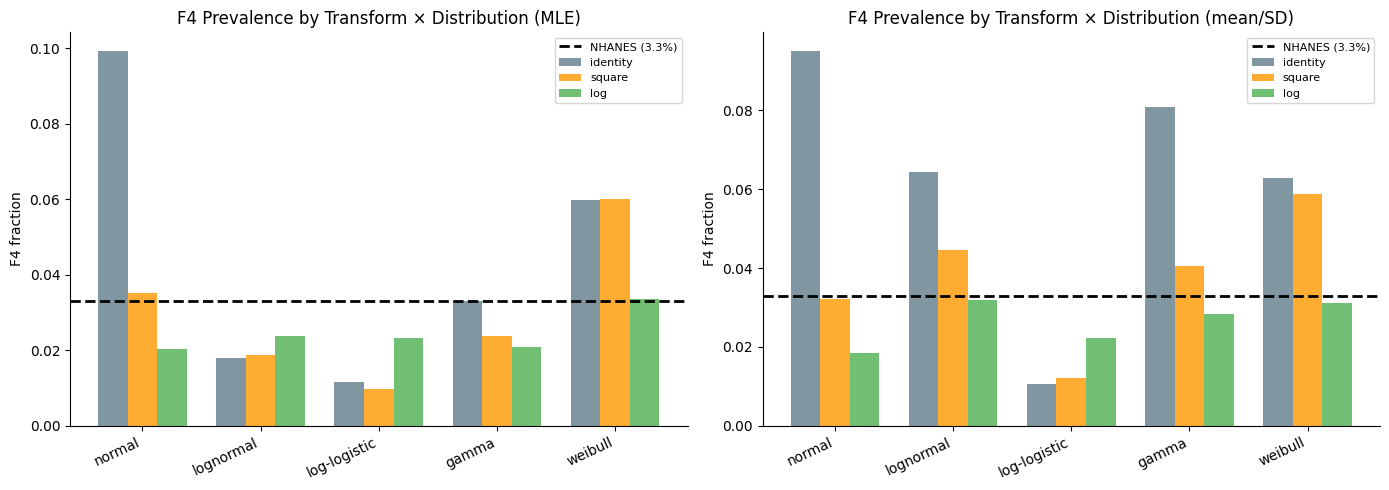

In [6]:
# Focus on F4 (cirrhosis) — the hardest stage to get right
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_idx, method in enumerate(['MLE', 'mean/SD']):
    ax = axes[ax_idx]
    sub = results_df[results_df['method'] == method].copy()

    # Pivot for grouped bar chart
    transforms = sub['transform'].unique()
    dists = sub['distribution'].unique()
    x = np.arange(len(dists))
    width = 0.25
    t_colors = {'identity': '#607D8B', 'square': '#FF9800', 'log': '#4CAF50'}

    for i, t in enumerate(transforms):
        t_sub = sub[sub['transform'] == t]
        vals = []
        for d in dists:
            row = t_sub[t_sub['distribution'] == d]
            vals.append(row['F4'].values[0] if len(row) > 0 else np.nan)
        ax.bar(x + (i - 1) * width, vals, width,
               label=t, color=t_colors.get(t, 'gray'), alpha=0.8)

    ax.axhline(nhanes_fibrosis['F4'], color='black', linestyle='--',
               linewidth=2, label=f'NHANES ({nhanes_fibrosis["F4"]:.1%})')
    ax.set_xticks(x)
    ax.set_xticklabels(dists, rotation=25, ha='right')
    ax.set_ylabel('F4 fraction')
    ax.set_title(f'F4 Prevalence by Transform × Distribution ({method})')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

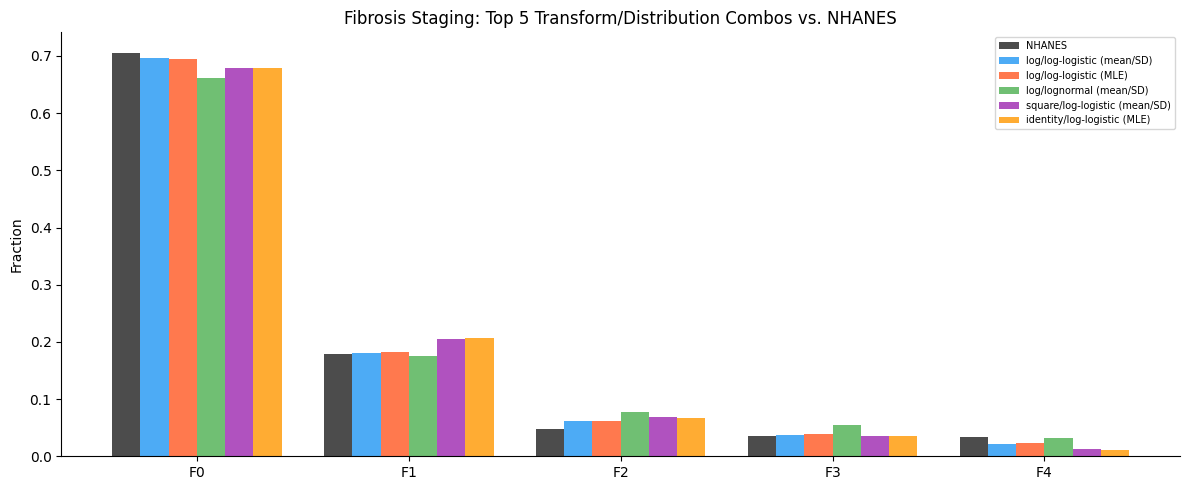

In [7]:
# Show all fibrosis stages for the top 5 best-fitting combinations
top5 = results_df.sort_values('F3F4_abs_err').head(5)

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(FIBROSIS_LABELS))
n_bars = len(top5) + 1  # +1 for NHANES
w = 0.8 / n_bars

ax.bar(x - 0.4 + w / 2, nhanes_fibrosis.values, w,
       label='NHANES', color='black', alpha=0.7)

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
for i, (_, row) in enumerate(top5.iterrows()):
    vals = [row[lab] for lab in FIBROSIS_LABELS]
    label = f"{row['transform']}/{row['distribution']} ({row['method']})"
    ax.bar(x - 0.4 + (i + 1.5) * w, vals, w,
           label=label, color=colors[i], alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title('Fibrosis Staging: Top 5 Transform/Distribution Combos vs. NHANES')
ax.legend(fontsize=7, loc='upper right')
sns.despine()
plt.tight_layout()
plt.show()

## 5. Q-Q Plots for Best Candidates

For the top 3 transform/distribution combinations, we show Q-Q plots
by age/sex strata with VCTE fibrosis cutoff grid lines.

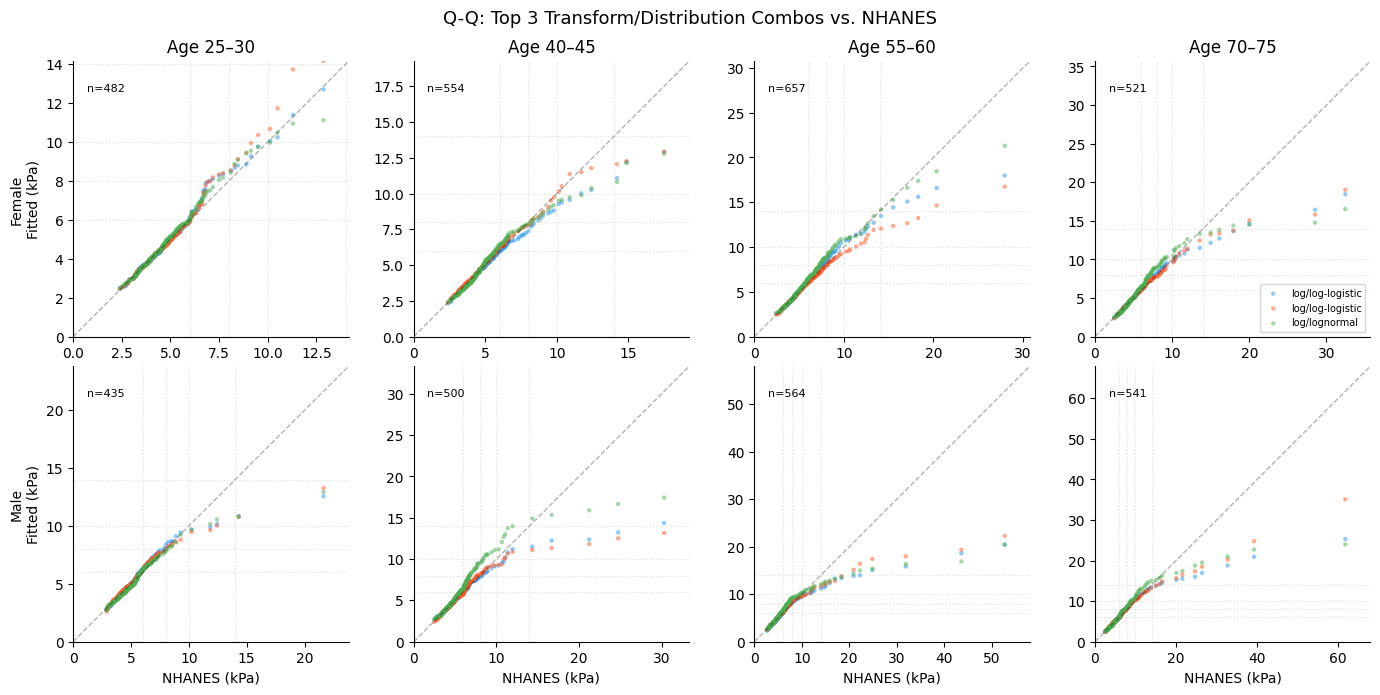

In [8]:
top3 = results_df.sort_values('F3F4_abs_err').head(3)
qq_ages = [(25, 30), (40, 45), (55, 60), (70, 75)]
qq_colors = ['#2196F3', '#FF5722', '#4CAF50']

fig, axes = plt.subplots(2, len(qq_ages), figsize=(14, 7))

for col, (a0, a1) in enumerate(qq_ages):
    for row, sex in enumerate(['Female', 'Male']):
        ax = axes[row, col]

        mask = ((nhanes_lsm['AGE'] >= a0) & (nhanes_lsm['AGE'] < a1)
                & (nhanes_lsm['SEX'] == sex))
        raw = nhanes_lsm.loc[mask, 'LSM_KPA'].values
        n = len(raw)
        if n < 10:
            ax.text(0.5, 0.5, 'n < 10', transform=ax.transAxes, ha='center')
            continue

        probs = np.linspace(0.01, 0.99, min(n, 200))
        eq = np.quantile(raw, probs)

        for i, (_, r) in enumerate(top3.iterrows()):
            t_name = r['transform']
            d_name = r['distribution']
            label = f"{t_name}/{d_name}"

            # Find transform functions
            for tn, fwd, inv in TRANSFORMS:
                if tn.split(' ')[0].lower() == t_name:
                    break

            dist, fit_kw = DISTS[d_name]
            t_data = fwd(raw)

            try:
                params = dist.fit(t_data, **fit_kw)
                t_samples = dist.rvs(*params, size=n, random_state=col * 2 + row + i * 100)
                kpa_samples = inv(t_samples)
                valid = np.isfinite(kpa_samples) & (kpa_samples > 0)
                kpa_samples = kpa_samples[valid]
                sq = np.quantile(kpa_samples, probs)
                ax.scatter(eq, sq, s=10, alpha=0.5, color=qq_colors[i],
                           edgecolors='none', label=label)
            except Exception:
                pass

        lim = eq.max() * 1.1
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)
        for thr in VCTE_CUTOFFS:
            if thr < lim:
                ax.axhline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
                ax.axvline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_aspect('equal')
        if row == 1:
            ax.set_xlabel('NHANES (kPa)')
        if col == 0:
            ax.set_ylabel(f'{sex}\nFitted (kPa)')
        ax.set_title(f'Age {a0}\u2013{a1}' if row == 0 else '')
        ax.text(0.05, 0.92, f'n={n}', transform=ax.transAxes, fontsize=8, va='top')
        if row == 0 and col == len(qq_ages) - 1:
            ax.legend(fontsize=7, loc='lower right')

plt.suptitle('Q-Q: Top 3 Transform/Distribution Combos vs. NHANES', fontsize=13)
sns.despine()
plt.tight_layout()
plt.show()

## 6. Per-Stratum Fibrosis Staging for Best Candidate

The pooled comparison hides age/sex variation. Here we compare
the best-fitting combination to NHANES within each age/sex stratum
to check that the fit is uniformly good and not just averaging out
offsetting errors.

Best combination: log + log-logistic (mean/SD)
  F3+F4 abs error: 0.0124
  F4: 2.23% (NHANES: 3.29%)



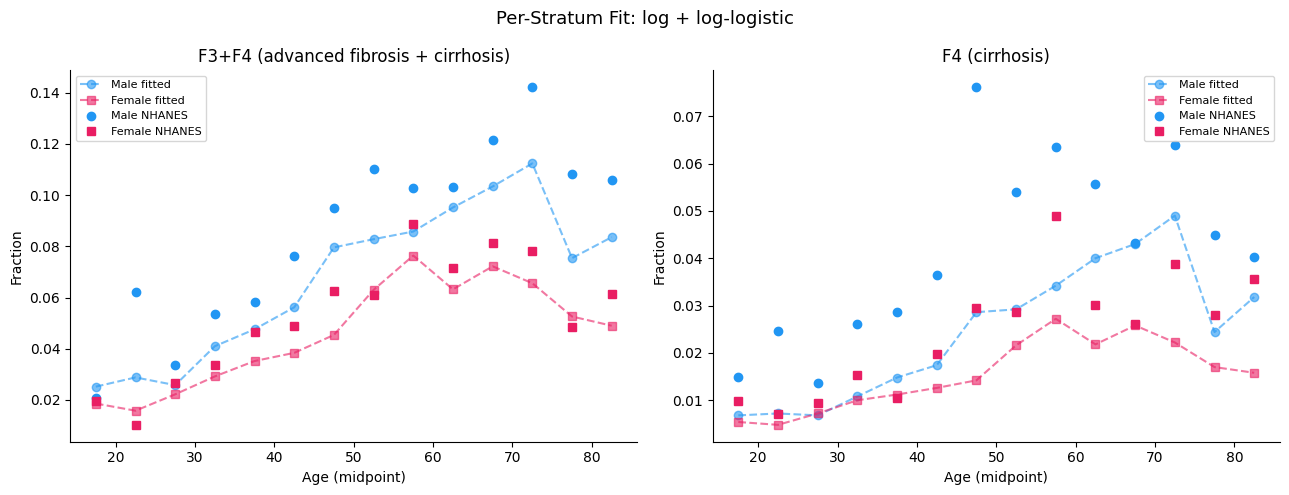

Per-stratum comparison:


,age_group,sex,n,nhanes_F3F4,fitted_F3F4,nhanes_F4,fitted_F4
0,15-20,Female,302,2.0%,1.9%,1.0%,0.5%
1,15-20,Male,352,2.1%,2.5%,1.5%,0.7%
2,20-25,Female,429,1.0%,1.6%,0.7%,0.5%
3,20-25,Male,445,6.2%,2.9%,2.5%,0.7%
4,25-30,Female,482,2.7%,2.2%,0.9%,0.7%
5,25-30,Male,435,3.4%,2.6%,1.4%,0.7%
6,30-35,Female,550,3.4%,2.9%,1.5%,1.0%
7,30-35,Male,522,5.4%,4.1%,2.6%,1.1%
8,35-40,Female,556,4.7%,3.5%,1.1%,1.1%
9,35-40,Male,432,5.8%,4.8%,2.9%,1.5%


In [9]:
best = results_df.sort_values('F3F4_abs_err').iloc[0]
t_name = best['transform']
d_name = best['distribution']
print(f'Best combination: {t_name} + {d_name} ({best["method"]})')
print(f'  F3+F4 abs error: {best["F3F4_abs_err"]:.4f}')
print(f'  F4: {best["F4"]:.2%} (NHANES: {nhanes_fibrosis["F4"]:.2%})\n')

for tn, fwd, inv in TRANSFORMS:
    if tn.split(' ')[0].lower() == t_name:
        break
dist, fit_kw = DISTS[d_name]

stratum_results = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    raw = g['LSM_KPA'].values
    w = g['WEIGHT'].values
    emp_fib = fibrosis_fractions(raw, w)

    t_data = fwd(raw)
    params = dist.fit(t_data, **fit_kw)
    t_samples = dist.rvs(*params, size=5000, random_state=42)
    kpa_samples = inv(t_samples)
    valid = np.isfinite(kpa_samples) & (kpa_samples > 0)
    sim_fib = fibrosis_fractions(kpa_samples[valid])

    stratum_results.append({
        'age_group': age_grp, 'sex': sex, 'n': len(raw),
        'nhanes_F3F4': emp_fib['F3'] + emp_fib['F4'],
        'fitted_F3F4': sim_fib['F3'] + sim_fib['F4'],
        'nhanes_F4': emp_fib['F4'],
        'fitted_F4': sim_fib['F4'],
    })

strat_df = pd.DataFrame(stratum_results)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], 'F3F4', 'F3+F4 (advanced fibrosis + cirrhosis)'),
    (axes[1], 'F4', 'F4 (cirrhosis)'),
]:
    for sex, color, marker in [('Male', '#2196F3', 'o'), ('Female', '#E91E63', 's')]:
        sub = strat_df[strat_df['sex'] == sex]
        age_mid = sub['age_group'].apply(
            lambda x: (int(x.split('-')[0]) + int(x.split('-')[1])) / 2)
        ax.errorbar(age_mid, sub[f'nhanes_{col}'], fmt=marker, color=color,
                    label=f'{sex} NHANES', markersize=6, linewidth=1.5, capsize=3)
        ax.plot(age_mid, sub[f'fitted_{col}'], marker=marker, color=color,
                linestyle='--', alpha=0.6, label=f'{sex} fitted')
    ax.set_xlabel('Age (midpoint)')
    ax.set_ylabel('Fraction')
    ax.set_title(title)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle(f'Per-Stratum Fit: {t_name} + {d_name}', fontsize=13)
plt.tight_layout()
plt.show()

print('Per-stratum comparison:')
display(strat_df.style.format({
    'nhanes_F3F4': '{:.1%}', 'fitted_F3F4': '{:.1%}',
    'nhanes_F4': '{:.1%}', 'fitted_F4': '{:.1%}',
}))

## 7. Vivarium Integration Test

Can we actually use the best transformation in vivarium? The approach:

1. Compute weighted mean and SD of **transformed** LSM per age/sex bin
2. Store those in the artifact as the exposure mean and SD
3. Run the simulation (vivarium samples in transformed space)
4. Apply the inverse transform to the simulated exposures

Step 4 requires a custom post-processing step since vivarium doesn't
know about the transform. We test this end-to-end.

In [10]:
from vivarium import InteractiveContext
from vivarium.framework.artifact import Artifact
from vivarium_public_health.population import BasePopulation
from vivarium_public_health.risks import Risk
from vivarium_public_health.risks.distributions import ContinuousDistribution
from loguru import logger

logger.disable('vivarium')

# Patch ContinuousDistribution bug (same as notebook 01)
_original_continuous_setup = ContinuousDistribution.setup

def _fixed_continuous_setup(self, builder):
    _original_continuous_setup(self, builder)
    builder.value.register_attribute_producer(
        self.exposure_params_name, source=self.parameters_table
    )

ContinuousDistribution.setup = _fixed_continuous_setup

# Use the best transformation
best = results_df.sort_values('F3F4_abs_err').iloc[0]
t_name = best['transform']
print(f'Testing vivarium with transform: {t_name}')

for tn, fwd, inv in TRANSFORMS:
    if tn.split(' ')[0].lower() == t_name:
        best_fwd, best_inv = fwd, inv
        break

# Compute mean/SD of transformed data per age/sex bin
YEAR_START = 2024
YEAR_END = 2025
INDEX_COLS = ['sex', 'age_start', 'age_end', 'year_start', 'year_end']

t_rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    raw = g['LSM_KPA'].values
    w = g['WEIGHT'].values
    t_data = best_fwd(raw)
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])
    t_rows.append({
        'age_start': float(age_start), 'age_end': float(age_end),
        'sex': sex,
        'mean_t': weighted_mean(t_data, w),
        'sd_t': weighted_std(t_data, w),
    })

t_summary = pd.DataFrame(t_rows)

# Build artifact tables from transformed summary
GBD_AGE_BINS_FULL = [
    (15, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45), (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 80), (80, 85), (85, 90),
    (90, 95), (95, 125),
]


def build_table(summary, value_col, year_start, year_end):
    rows = []
    for sex in ['Female', 'Male']:
        sub = summary[summary['sex'] == sex].sort_values('age_start')
        observed = dict(zip(sub['age_start'], sub[value_col]))
        last_val = None
        for age_start, age_end in GBD_AGE_BINS_FULL:
            val = observed.get(float(age_start), None)
            if val is not None:
                last_val = val
            elif last_val is not None:
                val = last_val
            else:
                val = sub[value_col].iloc[0] if len(sub) > 0 else 0.0
            rows.append({
                'sex': sex, 'age_start': float(age_start),
                'age_end': float(age_end),
                'year_start': year_start, 'year_end': year_end,
                'value': float(val),
            })
    return pd.DataFrame(rows)


t_exp_table = build_table(t_summary, 'mean_t', YEAR_START, YEAR_END)
t_sd_table = build_table(t_summary, 'sd_t', YEAR_START, YEAR_END)

# Population structure
pop_rows = []
for age_start, age_end in GBD_AGE_BINS_FULL:
    for sex in ['Female', 'Male']:
        pop_rows.append({
            'age_start': float(age_start), 'age_end': float(age_end),
            'sex': sex, 'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': 1000.0,
        })
pop_structure = pd.DataFrame(pop_rows)

# Mortality (placeholder)
acmr_rows = []
tmrle_rows = []
for age_start, age_end in GBD_AGE_BINS_FULL:
    for sex in ['Female', 'Male']:
        acmr_rows.append({
            'sex': sex, 'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': 1e-9,
        })
        tmrle_rows.append({
            'sex': sex, 'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START, 'year_end': YEAR_END,
            'value': max(100 - age_start, 0.5),
        })
acmr_table = pd.DataFrame(acmr_rows)
tmrle_table = pd.DataFrame(tmrle_rows)

YEAR_BINS = [(2020 + i, 2021 + i) for i in range(11)]

def expand_years(df, year_pairs):
    pieces = []
    for ys, ye in year_pairs:
        chunk = df.copy()
        chunk['year_start'] = ys
        chunk['year_end'] = ye
        pieces.append(chunk)
    return pd.concat(pieces, ignore_index=True).set_index(INDEX_COLS)

# Write artifact
OUTPUT_DIR = os.path.join('.', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
T_ARTIFACT_PATH = os.path.join(OUTPUT_DIR, f'nhanes_lsm_{t_name}_transform.hdf')
if os.path.exists(T_ARTIFACT_PATH):
    os.remove(T_ARTIFACT_PATH)

t_artifact = Artifact(T_ARTIFACT_PATH)
t_artifact.write('population.location', 'United States')
t_artifact.write('population.structure', expand_years(pop_structure, YEAR_BINS))
t_artifact.write('population.theoretical_minimum_risk_life_expectancy',
                 expand_years(tmrle_table, YEAR_BINS))
t_artifact.write('cause.all_causes.cause_specific_mortality_rate',
                 expand_years(acmr_table, YEAR_BINS))
t_artifact.write('risk_factor.liver_stiffness.distribution', 'lognormal')
t_artifact.write('risk_factor.liver_stiffness.exposure',
                 expand_years(t_exp_table, YEAR_BINS))
t_artifact.write('risk_factor.liver_stiffness.exposure_standard_deviation',
                 expand_years(t_sd_table, YEAR_BINS))

# Run simulation
t_sim = InteractiveContext(
    components=[BasePopulation(), Risk('risk_factor.liver_stiffness')],
    configuration={
        'input_data': {'artifact_path': os.path.abspath(T_ARTIFACT_PATH)},
        'interpolation': {'order': 0, 'extrapolate': True},
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': 10_000,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    },
)

t_pop = t_sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
t_pop = t_pop.rename(columns={'liver_stiffness.exposure': 'transformed_value'})

# Inverse-transform to kPa
t_pop['lsm_kpa'] = best_inv(t_pop['transformed_value'].values)

# Handle any invalid values from inverse transform
valid = np.isfinite(t_pop['lsm_kpa']) & (t_pop['lsm_kpa'] > 0)
print(f'Valid after inverse transform: {valid.sum()}/{len(t_pop)}')

t_fibrosis = fibrosis_fractions(t_pop.loc[valid, 'lsm_kpa'].values)

print(f'\nFibrosis staging with {t_name} transform + lognormal in vivarium:')
for lab in FIBROSIS_LABELS:
    err = t_fibrosis[lab] - nhanes_fibrosis[lab]
    print(f'  {lab}: {t_fibrosis[lab]:.2%} (NHANES: {nhanes_fibrosis[lab]:.2%}, '
          f'err: {"+" if err > 0 else ""}{err:.2%})')

Testing vivarium with transform: log


/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium/framework/artifact/artifact.py:69: UserWarning: No artifact found at outputs/nhanes_lsm_log_transform.hdf. Building new artifact.
  warnings.warn(f"No artifact found at {path}. Building new artifact.")


Valid after inverse transform: 10000/10000

Fibrosis staging with log transform + lognormal in vivarium:
  F0: 65.93% (NHANES: 70.60%, err: -4.67%)
  F1: 17.87% (NHANES: 17.81%, err: +0.06%)
  F2: 7.92% (NHANES: 4.76%, err: +3.16%)
  F3: 5.30% (NHANES: 3.54%, err: +1.76%)
  F4: 2.98% (NHANES: 3.29%, err: -0.31%)


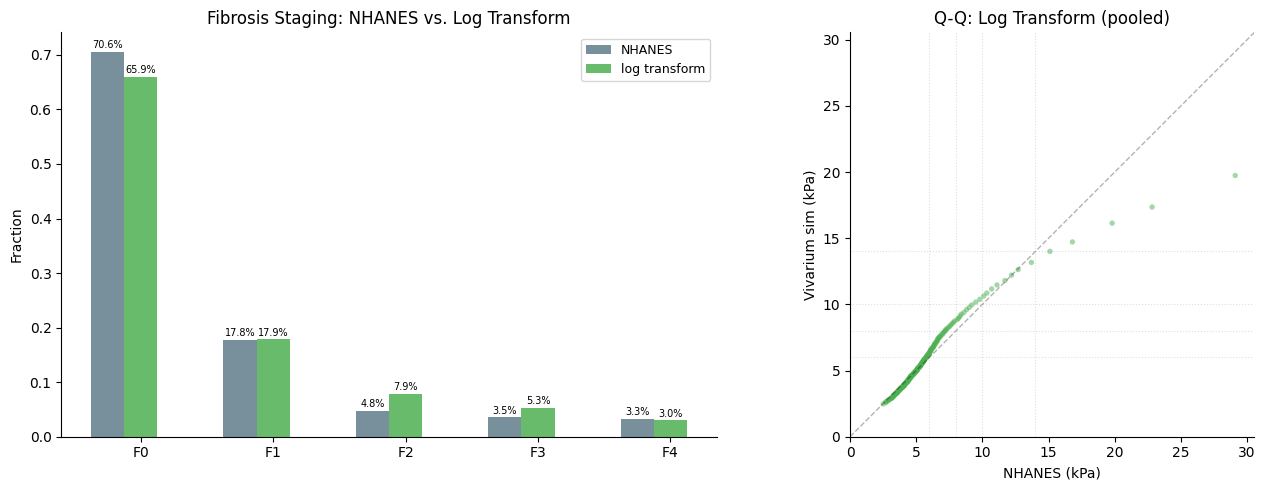

In [11]:
# Side-by-side comparison: original vs transformed vivarium simulation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: fibrosis staging bar chart
ax = axes[0]
x = np.arange(len(FIBROSIS_LABELS))
w = 0.25
ax.bar(x - w, nhanes_fibrosis.values, w,
       label='NHANES', color='#607D8B', alpha=0.85)
ax.bar(x, t_fibrosis.values, w,
       label=f'{t_name} transform', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(FIBROSIS_LABELS)
ax.set_ylabel('Fraction')
ax.set_title(f'Fibrosis Staging: NHANES vs. {t_name.title()} Transform')
ax.legend(fontsize=9)
for i in range(len(FIBROSIS_LABELS)):
    for frac, dx in zip(
        [nhanes_fibrosis.values[i], t_fibrosis.values[i]],
        [-w, 0]):
        ax.text(i + dx, frac + 0.003, f'{frac:.1%}',
                ha='center', va='bottom', fontsize=7)
sns.despine(ax=ax)

# Right: Q-Q plot (pooled)
ax = axes[1]
valid_kpa = t_pop.loc[valid, 'lsm_kpa'].values
emp_all = nhanes_lsm['LSM_KPA'].values
probs = np.linspace(0.01, 0.99, 200)
eq = np.quantile(emp_all, probs)
sq = np.quantile(valid_kpa, probs)

ax.scatter(eq, sq, s=15, alpha=0.5, color='#4CAF50', edgecolors='none')
lim = max(eq.max(), sq.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', alpha=0.3, linewidth=1)
for thr in VCTE_CUTOFFS:
    if thr < lim:
        ax.axhline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
        ax.axvline(thr, color='gray', linestyle=':', alpha=0.25, linewidth=0.8)
ax.set_xlim(0, min(lim, 40))
ax.set_ylim(0, min(lim, 40))
ax.set_aspect('equal')
ax.set_xlabel('NHANES (kPa)')
ax.set_ylabel('Vivarium sim (kPa)')
ax.set_title(f'Q-Q: {t_name.title()} Transform (pooled)')
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## Summary

In [12]:
print('=== Transformation Experiment Results ===')
print(f'\nNHANES target: F3={nhanes_fibrosis["F3"]:.2%}, F4={nhanes_fibrosis["F4"]:.2%}')
print(f'\nTop 5 combinations by F3+F4 error:\n')

top5 = results_df.sort_values('F3F4_abs_err').head(5)
for _, r in top5.iterrows():
    print(f'  {r["transform"]:10s} + {r["distribution"]:13s} ({r["method"]:6s}): '
          f'F3={r["F3"]:.2%}, F4={r["F4"]:.2%}, '
          f'F3+F4 err={r["F3F4_abs_err"]:.4f}')

print(f'\nVivarium integration ({t_name} transform + lognormal):')
print(f'  F3={t_fibrosis["F3"]:.2%} (target {nhanes_fibrosis["F3"]:.2%})')
print(f'  F4={t_fibrosis["F4"]:.2%} (target {nhanes_fibrosis["F4"]:.2%})')

=== Transformation Experiment Results ===

NHANES target: F3=3.54%, F4=3.29%

Top 5 combinations by F3+F4 error:

  log        + log-logistic  (mean/SD): F3=3.73%, F4=2.23%, F3+F4 err=0.0124
  log        + log-logistic  (MLE   ): F3=3.81%, F4=2.31%, F3+F4 err=0.0125
  log        + lognormal     (mean/SD): F3=5.40%, F4=3.20%, F3+F4 err=0.0195
  square     + log-logistic  (mean/SD): F3=3.54%, F4=1.21%, F3+F4 err=0.0208
  identity   + log-logistic  (MLE   ): F3=3.49%, F4=1.15%, F3+F4 err=0.0219

Vivarium integration (log transform + lognormal):
  F3=5.30% (target 3.54%)
  F4=2.98% (target 3.29%)
